[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vicradon/ml-workspace/blob/main/shape_detection/notebook.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/vicradon/shape-detection)

In [1]:
IMAGE_DIMENSION=200

import os
os.environ["IMAGE_DIMENSION"] = str(IMAGE_DIMENSION)

In [2]:
%%bash
wget -qO shapegen https://github.com/vicradon/shapegen/releases/download/v0.0.1/shapegen-linux-amd64
cd /kaggle/working
chmod +x shapegen
./shapegen -size $IMAGE_DIMENSION -n 200
unzip -qo shape_dataset_coco.zip


  ╔═══════════════════════════════════════╗
  ║    Shape Dataset Generator  v1.0      ║
  ╚═══════════════════════════════════════╝

  Classes  : 7  (triangle, quadrilateral, pentagon, hexagon, heptagon, octagon, decagon)
  Images   : 200 per class  (1400 total)
  Size     : 200x200 px
  Format   : COCO
  Workers  : 4
  Output   : shape_dataset_coco.zip

  Generating images…
  done [████████████████████████████████████████] 100%  1400/1400 1400/1400
  ✓ Generated 1400 images in 1.942s

  Packing COCO ZIP…
  ✓ ZIP written in 215ms  (4.9 MB)

  ┌─────────────────────────────────────┐
  │  Output → shape_dataset_coco.zip    │
  └─────────────────────────────────────┘



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import random

In [4]:
!pip install torchview onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 82.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 11.2 MB/s eta 0:00:00


In [5]:
import json
from itertools import islice

with open("/kaggle/working/annotations/instances.json", "r") as annotation_data:
    content = annotation_data.read()
    
annotation_data = json.loads(content)

categories = pd.DataFrame(annotation_data["categories"])
images = pd.DataFrame(annotation_data["images"])
annotations = pd.DataFrame(annotation_data["annotations"])

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np

img_to_label = annotations.groupby("image_id")["category_id"].first()
images["label"] = images["id"].map(img_to_label)

label_map = {cat_id: i for i, cat_id in enumerate(sorted(images["label"].unique()))}
images["label"] = images["label"].map(label_map)

class ShapeDataset(Dataset):
    def __init__(self, df, root_dir):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["file_name"])
        image = Image.open(img_path).convert("L")
        image = torch.tensor(np.array(image), dtype=torch.float32) / 255.0
        image = image.unsqueeze(0)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label

dataset = ShapeDataset(images, "/kaggle/working")

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

print({train_size, val_size, test_size})

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


{210, 979, 211}


In [7]:
categories

,id,name,supercategory
0,1,triangle,shape
1,2,quadrilateral,shape
2,3,pentagon,shape
3,4,hexagon,shape
4,5,heptagon,shape
5,6,octagon,shape
6,7,decagon,shape


In [8]:
images.head()

,id,file_name,width,height,label
0,1,images/triangle_0000.png,200,200,0
1,2,images/triangle_0001.png,200,200,0
2,3,images/triangle_0002.png,200,200,0
3,4,images/triangle_0003.png,200,200,0
4,5,images/triangle_0004.png,200,200,0


In [9]:
annotations.head()

,id,image_id,category_id,bbox,area,iscrowd
0,1,1,1,"[45.58, 52.7, 95.7, 92.74]",8875.27,0
1,2,2,1,"[50.16, 52.34, 105.38, 106.29]",11200.68,0
2,3,3,1,"[75.13, 43.96, 85.06, 83.15]",7072.54,0
3,4,4,1,"[26.82, 46.87, 124.04, 125.56]",15573.70,0
4,5,5,1,"[34.78, 25, 129.38, 114.58]",14824.06,0


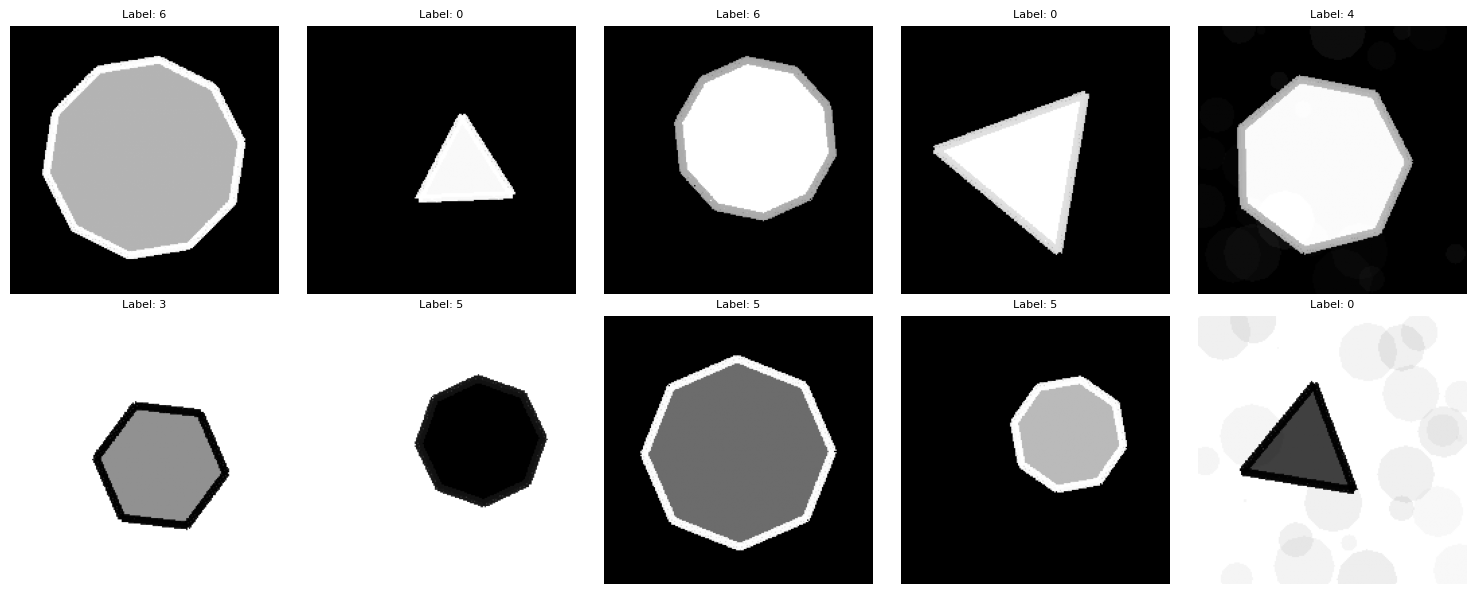

In [10]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
images_batch, labels_batch = batch

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = images_batch[i].squeeze(0).numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {labels_batch[i].item()}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [22]:
class ShapeClassifier:
    def __init__(self, network, categories_df, train_loader, val_loader, test_loader, test_dataset,
                 lr=1e-3, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = network.to(self.device)
        self.categories_df = categories_df
        self.class_names = categories_df["name"].tolist()
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.test_dataset = test_dataset
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.history = []

    def train(self, epochs=200, log_every=10):
        for epoch in range(1, epochs + 1):
            # --- Training ---
            self.model.train()
            total_loss, correct, total = 0, 0, 0
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            train_acc = correct / total

            # --- Validation ---
            self.model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for images, labels in self.val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
            val_acc = val_correct / val_total

            self.history.append({
                "epoch": epoch,
                "train_loss": total_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            })

            if epoch % log_every == 0 or epoch == 1:
                print(f"Epoch {epoch}/{epochs} | "
                      f"Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    def evaluate(self):
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        accuracy = (all_preds == all_labels).mean()

        print(f"Test Accuracy: {accuracy * 100:.2f}%")
        for i, name in enumerate(self.class_names):
            mask = all_labels == i
            class_acc = (all_preds[mask] == all_labels[mask]).mean() if mask.sum() > 0 else 0
            print(f"  {name}: {class_acc * 100:.2f}%")

        return all_preds, all_labels

    def plot_history(self):
        epochs = [h["epoch"] for h in self.history]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(epochs, [h["train_loss"] for h in self.history], label="Train Loss")
        ax1.plot(epochs, [h["val_loss"] for h in self.history], label="Val Loss")
        ax1.set_title("Loss")
        ax1.set_xlabel("Epoch")
        ax1.legend()

        ax2.plot(epochs, [h["train_acc"] for h in self.history], label="Train Acc")
        ax2.plot(epochs, [h["val_acc"] for h in self.history], label="Val Acc")
        ax2.set_title("Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.legend()

        plt.suptitle(f"{self.model.__class__.__name__} — Training History", fontweight="bold")
        plt.tight_layout()
        plt.show()

    def visualize_predictions(self, num_samples=5):
        self.model.eval()
        indices = random.sample(range(len(self.test_dataset)), num_samples)
        fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
        if num_samples == 1:
            axes = [axes]

        with torch.no_grad():
            for ax, idx in zip(axes, indices):
                image, label = self.test_dataset[idx]
                output = self.model(image.unsqueeze(0).to(self.device))
                pred = torch.argmax(output, dim=1).item()
                true_name = self.class_names[label.item()]
                pred_name = self.class_names[pred]
                correct = pred == label.item()
                ax.imshow(image.squeeze(0).cpu().numpy(), cmap="gray")
                ax.set_title(
                    f"Pred: {pred_name}\nTrue: {true_name}",
                    color="green" if correct else "red",
                    fontsize=12
                )
                ax.axis("off")

        plt.suptitle(f"{self.model.__class__.__name__} — Predictions", fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()
    
    def export_onnx(self, path="model.onnx"):
        import torch.onnx
        import onnx
        import os
    
        self.model.eval()
        dummy = torch.zeros(1, 1, self.model.image_size, self.model.image_size).to(self.device)
    
        torch.onnx.export(
            self.model,
            dummy,
            path,
            dynamo=True,
            input_names=["image"],
            output_names=["logits"],
            dynamic_axes={
                "image":  {0: "batch_size"},
                "logits": {0: "batch_size"},
            },
            opset_version=17,
        )
    
        # Inline external weights into a single file
        onnx_model = onnx.load(path, load_external_data=True)
        onnx.save_model(onnx_model, path, save_as_external_data=False)
    
        data_file = path + ".data"
        if os.path.exists(data_file):
            os.remove(data_file)
    
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"Exported to {path} ({size_mb:.1f} MB)")

    def verify_onnx(self, path="model.onnx"):
        import onnx
        model = onnx.load(path)
        onnx.checker.check_model(model)
        print(f"✅ {path} is valid")
        print(f"  opset version : {model.opset_import[0].version}")
        print(f"  inputs        : {[i.name for i in model.graph.input]}")
        print(f"  outputs       : {[o.name for o in model.graph.output]}")
    
    def infer_onnx(self, path="model.onnx", num_samples=5):
        import onnxruntime as ort
        import random
    
        session = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
        input_name = session.get_inputs()[0].name
    
        self.model.eval()
        indices = random.sample(range(len(self.test_dataset)), num_samples)
    
        fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
        if num_samples == 1:
            axes = [axes]
    
        for ax, idx in zip(axes, indices):
            image, label = self.test_dataset[idx]
            inp = image.unsqueeze(0).numpy()                        # (1, 1, H, W)
            logits = session.run(None, {input_name: inp})[0]        # (1, num_classes)
            pred = int(np.argmax(logits, axis=1))
    
            true_name = self.class_names[label.item()]
            pred_name = self.class_names[pred]
            correct = pred == label.item()
    
            ax.imshow(image.squeeze(0).numpy(), cmap="gray")
            ax.set_title(
                f"Pred: {pred_name}\nTrue: {true_name}",
                color="green" if correct else "red",
                fontsize=12,
            )
            ax.axis("off")
    
        plt.suptitle(f"ONNX inference — {path}", fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

In [12]:
import torch
import torch.nn as nn

class VanillaNeuralNetwork(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size
        self.input_dim = image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), self.input_dim)
        return self.model(x)

Epoch 1/200 | Train Loss: 128.7953 | Train Acc: 0.1389 | Val Loss: 16.7345 | Val Acc: 0.1619
Epoch 10/200 | Train Loss: 60.5446 | Train Acc: 0.1645 | Val Loss: 13.7277 | Val Acc: 0.1667
Epoch 20/200 | Train Loss: 59.3928 | Train Acc: 0.1757 | Val Loss: 13.4533 | Val Acc: 0.2095
Epoch 30/200 | Train Loss: 58.8342 | Train Acc: 0.1839 | Val Loss: 13.3707 | Val Acc: 0.2048
Epoch 40/200 | Train Loss: 57.7388 | Train Acc: 0.2063 | Val Loss: 13.2714 | Val Acc: 0.2190
Epoch 50/200 | Train Loss: 60.3811 | Train Acc: 0.1410 | Val Loss: 13.6604 | Val Acc: 0.1619
Epoch 60/200 | Train Loss: 60.3151 | Train Acc: 0.1512 | Val Loss: 13.6421 | Val Acc: 0.1238
Epoch 70/200 | Train Loss: 60.3238 | Train Acc: 0.1512 | Val Loss: 13.6435 | Val Acc: 0.1238
Epoch 80/200 | Train Loss: 60.3157 | Train Acc: 0.1512 | Val Loss: 13.6429 | Val Acc: 0.1238
Epoch 90/200 | Train Loss: 60.3172 | Train Acc: 0.1512 | Val Loss: 13.6432 | Val Acc: 0.1238
Epoch 100/200 | Train Loss: 60.3222 | Train Acc: 0.1512 | Val Loss: 13

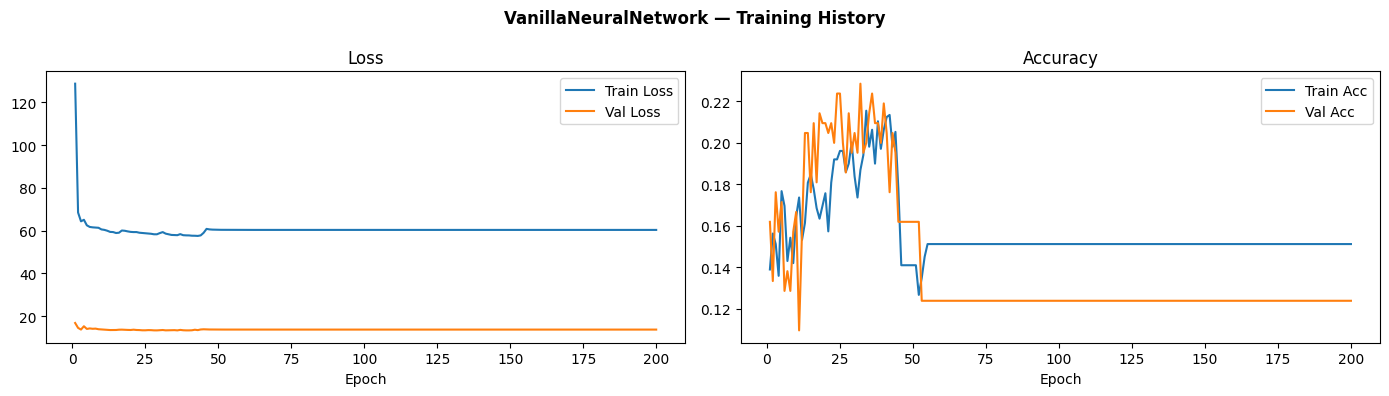

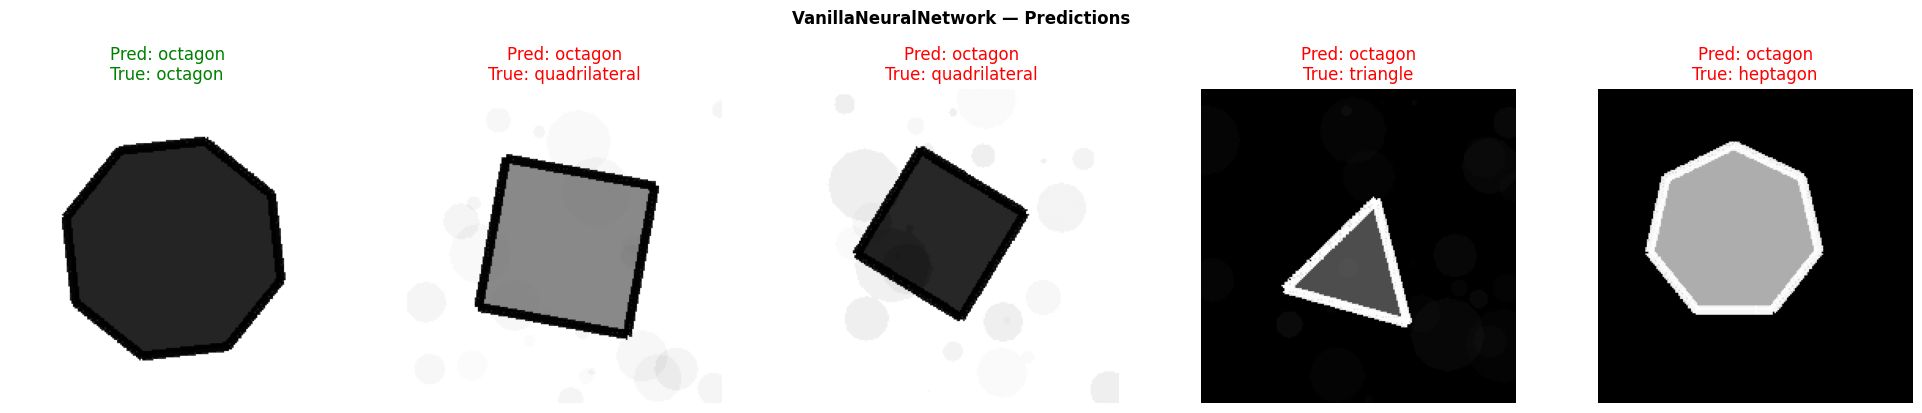

In [13]:
classifier = ShapeClassifier(
    network=VanillaNeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=7),
    categories_df=categories,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset=test_dataset,
    lr=1e-3,
)

classifier.train(epochs=200, log_every=10)
classifier.evaluate()
classifier.plot_history()
classifier.visualize_predictions(num_samples=5)

In [14]:
class ConvNet(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1, 200, 200) -> (32, 200, 200)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (32, 100, 100)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (64, 100, 100)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (64, 50, 50)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# -> (128, 50, 50)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (128, 25, 25)
        )

        # derive flat size dynamically so image_size changes don't break anything
        flat_size = self._get_flat_size(image_size)

        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _get_flat_size(self, image_size):
        dummy = torch.zeros(1, 1, image_size, image_size)
        out = self.features(dummy)
        return out.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

Epoch 1/200 | Train Loss: 279.8621 | Train Acc: 0.1665 | Val Loss: 13.6138 | Val Acc: 0.1619
Epoch 10/200 | Train Loss: 57.5761 | Train Acc: 0.1818 | Val Loss: 13.0556 | Val Acc: 0.2048
Epoch 20/200 | Train Loss: 54.9836 | Train Acc: 0.2288 | Val Loss: 12.9945 | Val Acc: 0.1762
Epoch 30/200 | Train Loss: 51.8237 | Train Acc: 0.2646 | Val Loss: 12.9110 | Val Acc: 0.1905
Epoch 40/200 | Train Loss: 47.6453 | Train Acc: 0.3350 | Val Loss: 12.8670 | Val Acc: 0.1857
Epoch 50/200 | Train Loss: 44.6226 | Train Acc: 0.3994 | Val Loss: 12.9460 | Val Acc: 0.2333
Epoch 60/200 | Train Loss: 40.5253 | Train Acc: 0.4382 | Val Loss: 14.3833 | Val Acc: 0.2238
Epoch 70/200 | Train Loss: 39.6322 | Train Acc: 0.4454 | Val Loss: 15.1933 | Val Acc: 0.2190
Epoch 80/200 | Train Loss: 38.0573 | Train Acc: 0.4637 | Val Loss: 15.0802 | Val Acc: 0.2381
Epoch 90/200 | Train Loss: 37.4893 | Train Acc: 0.4842 | Val Loss: 16.0663 | Val Acc: 0.2143
Epoch 100/200 | Train Loss: 36.9186 | Train Acc: 0.4903 | Val Loss: 16

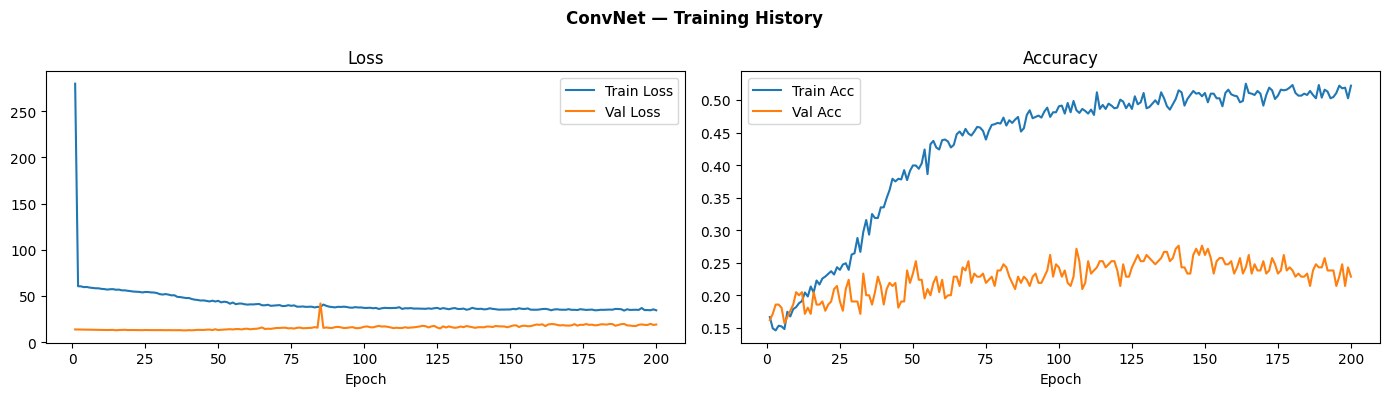

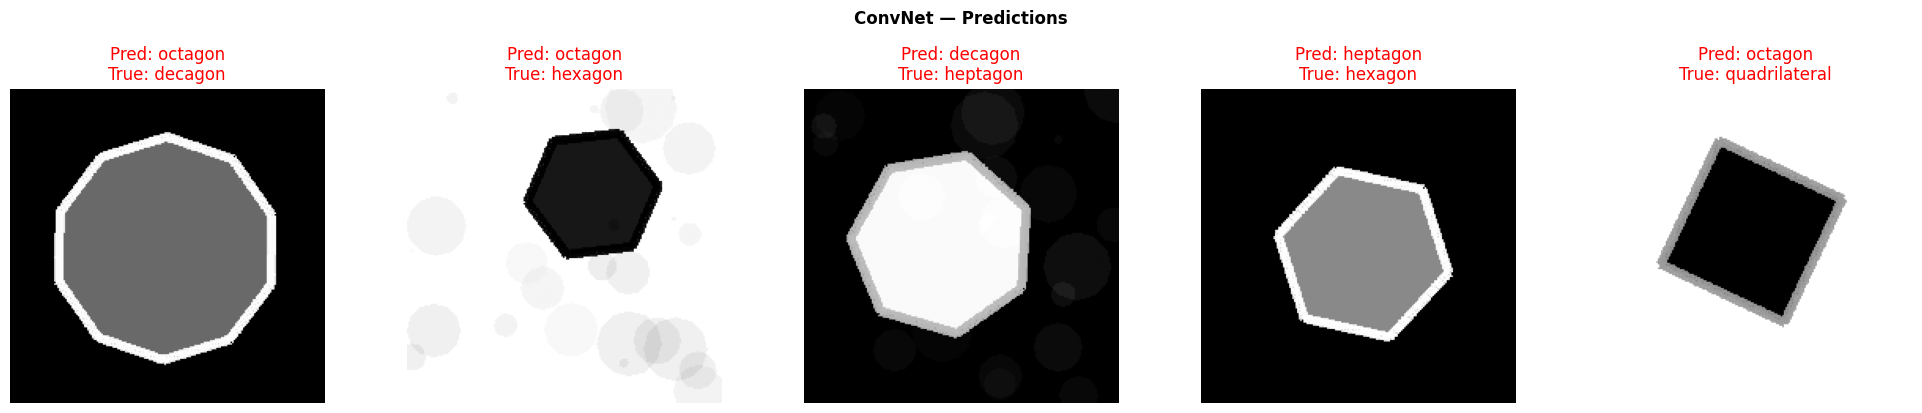

In [15]:
classifier = ShapeClassifier(
    network=ConvNet(image_size=IMAGE_DIMENSION, num_classes=7),
    categories_df=categories,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset=test_dataset,
    lr=1e-3,
)

classifier.train(epochs=200, log_every=10)
classifier.evaluate()
classifier.plot_history()
classifier.visualize_predictions(num_samples=5)

In [16]:
from torchview import draw_graph
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display
import os

def compare_architectures(models_and_names, image_size, save_dir="."):
    paths = []
    for model, name in models_and_names:
        graph = draw_graph(
            model,
            input_size=(1, 1, image_size, image_size),
            expand_nested=True,
            graph_name=name,
            save_graph=False,
        )

        dg = graph.visual_graph
        dg.graph_attr.update({
            "dpi": "200",
            "ranksep": "0.6", 
            "nodesep": "0.4", 
            "size": "12,24",
        })
        dg.node_attr.update({
            "fontsize": "11",
            "width": "2.5",
            "height": "0.5",
        })

        out_path = os.path.join(save_dir, name)
        dg.render(filename=out_path, format="png", cleanup=True)
        paths.append((f"{out_path}.png", name))

    fig, axes = plt.subplots(1, len(paths), figsize=(10 * len(paths), 20))
    if len(paths) == 1:
        axes = [axes]

    for ax, (path, name) in zip(axes, paths):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(name, fontsize=14, fontweight="bold", pad=12)
        ax.axis("off")

    plt.suptitle("Architecture Comparison", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

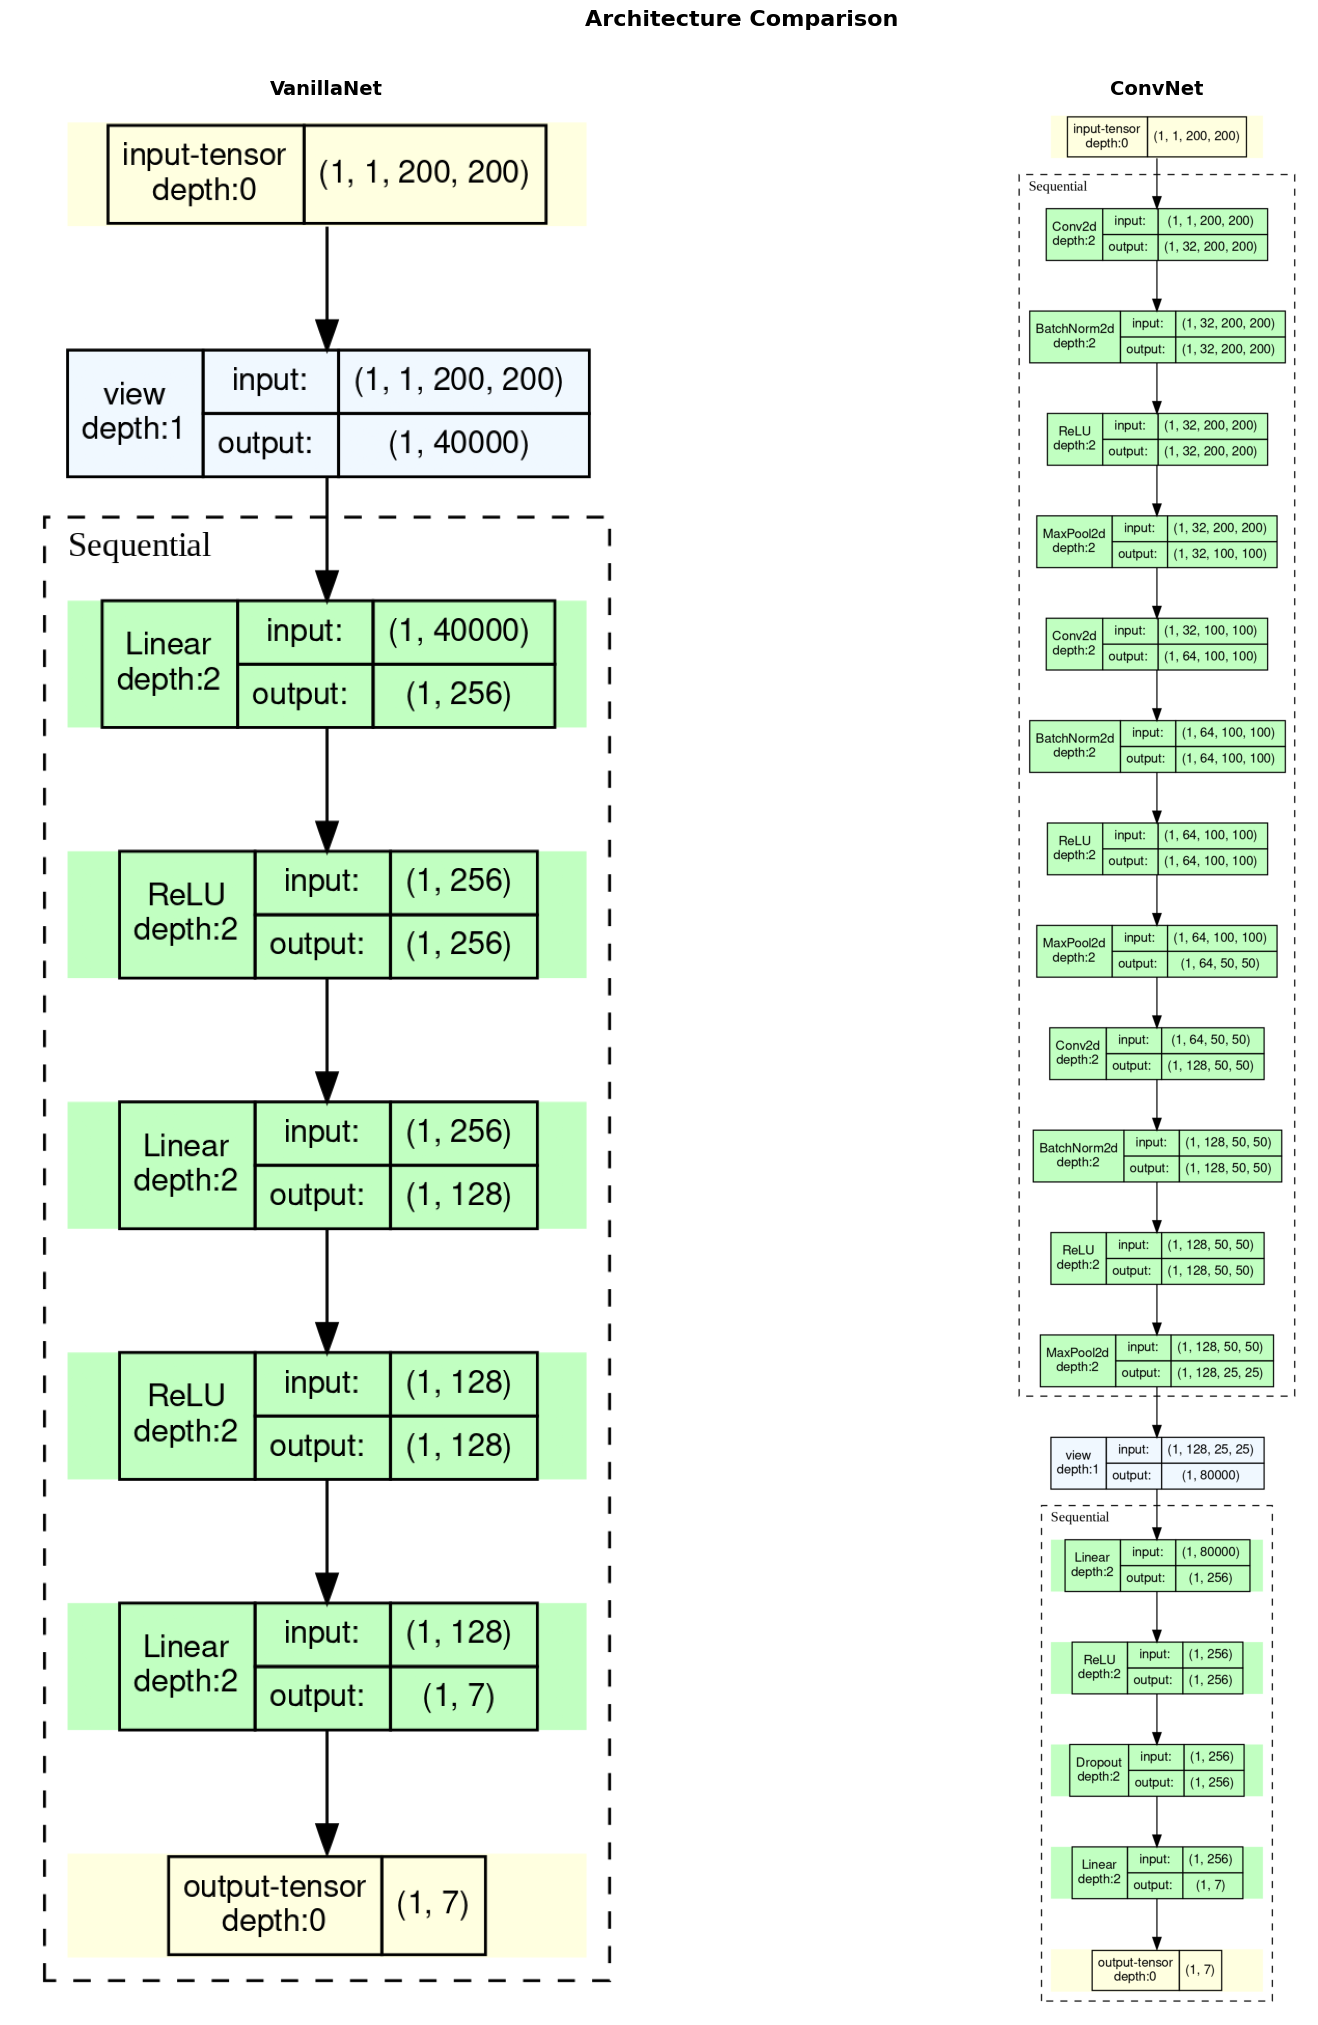

In [17]:
vanilla = VanillaNeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=7)
conv    = ConvNet(image_size=IMAGE_DIMENSION, num_classes=7)

compare_architectures(
    models_and_names=[
        (vanilla, "VanillaNet"),
        (conv,    "ConvNet"),
    ],
    image_size=IMAGE_DIMENSION,
)

In [18]:
import torchvision.models as models

class ResNet18Transfer(nn.Module):
    def __init__(self, num_classes, image_size=IMAGE_DIMENSION, freeze_base=True):
        super().__init__()
        self.image_size = image_size
        
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        if freeze_base:
            for param in base.parameters():
                param.requires_grad = False
        
        base.fc = nn.Sequential(
            nn.Linear(base.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
        self.model = base

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)  # grayscale -> 3 channel
        return self.model(x)
    
    def unfreeze(self, layers=["layer4", "layer3"]):
        for name, param in self.model.named_parameters():
            if any(name.startswith(l) for l in layers):
                param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


Epoch 1/200 | Train Loss: 49.6439 | Train Acc: 0.3575 | Val Loss: 8.6258 | Val Acc: 0.5810
Epoch 10/200 | Train Loss: 15.6395 | Train Acc: 0.8141 | Val Loss: 3.0844 | Val Acc: 0.8667
Epoch 20/200 | Train Loss: 12.3296 | Train Acc: 0.8488 | Val Loss: 2.6578 | Val Acc: 0.8667
Epoch 30/200 | Train Loss: 12.4151 | Train Acc: 0.8355 | Val Loss: 2.3961 | Val Acc: 0.8667
Epoch 40/200 | Train Loss: 10.2334 | Train Acc: 0.8703 | Val Loss: 2.2744 | Val Acc: 0.8667
Epoch 50/200 | Train Loss: 8.3011 | Train Acc: 0.9040 | Val Loss: 2.5645 | Val Acc: 0.8476
Epoch 60/200 | Train Loss: 7.7237 | Train Acc: 0.9040 | Val Loss: 2.4969 | Val Acc: 0.8714
Epoch 70/200 | Train Loss: 8.0623 | Train Acc: 0.8979 | Val Loss: 2.4613 | Val Acc: 0.8571
Epoch 80/200 | Train Loss: 5.5062 | Train Acc: 0.9428 | Val Loss: 2.2546 | Val Acc: 0.8667
Epoch 90/200 | Train Loss: 6.8932 | Train Acc: 0.9101 | Val Loss: 2.6492 | Val Acc: 0.8476
Epoch 100/200 | Train Loss: 5.2523 | Train Acc: 0.9448 | Val Loss: 2.6656 | Val Acc: 0

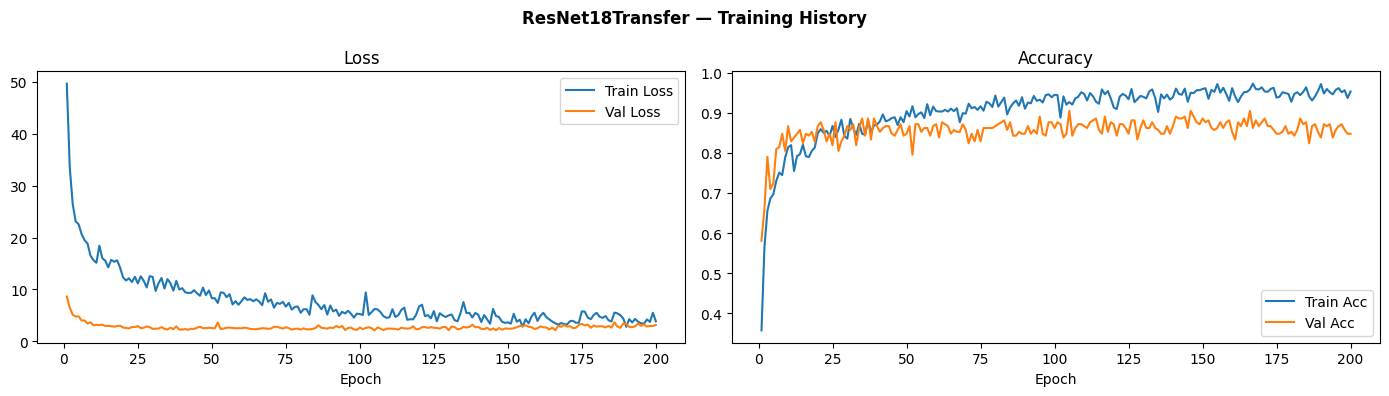

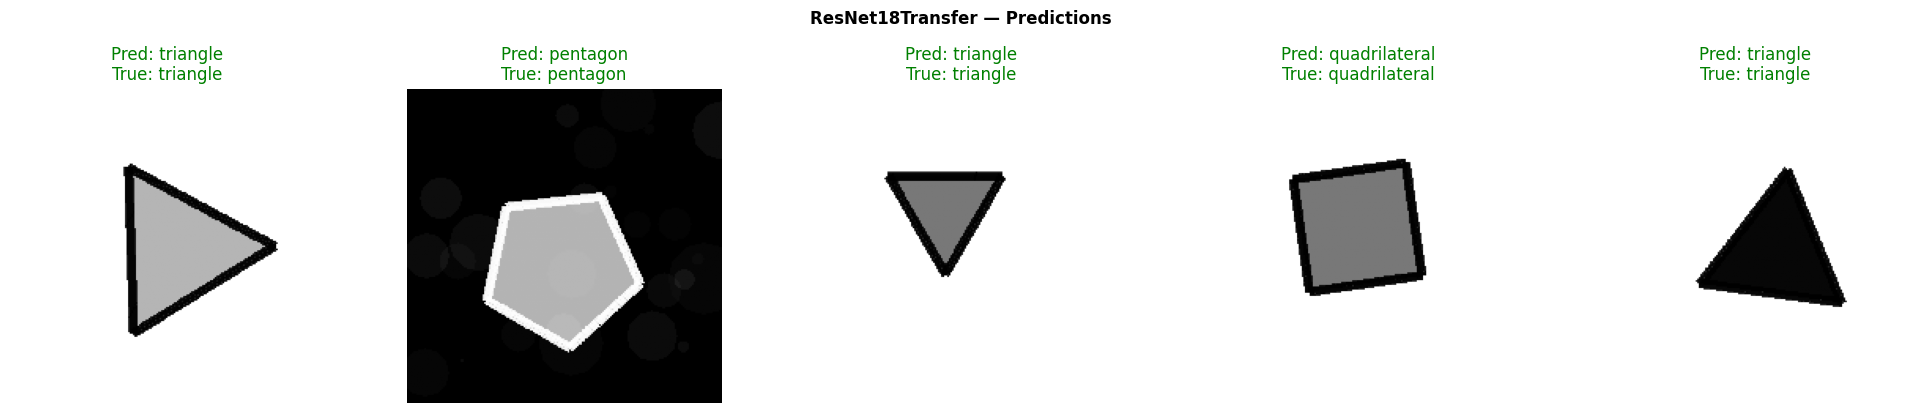

In [19]:
classifier = ShapeClassifier(
    network=ResNet18Transfer(num_classes=7, freeze_base=True),
    categories_df=categories,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    test_dataset=test_dataset,
    lr=1e-3,
)

classifier.train(epochs=200, log_every=10)
classifier.evaluate()
classifier.plot_history()
classifier.visualize_predictions(num_samples=5)

/tmp/ipykernel_55/1234673638.py:137: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0401 11:05:11.847000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0401 11:05:12.600000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligne

[torch.onnx] Obtain model graph for `ResNet18Transfer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18Transfer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 41 of general pattern rewrite rules.
Exported to resnet_18.onnx
✅ resnet_18.onnx is valid
  opset version : 18
  inputs        : ['image']
  outputs       : ['logits']


/tmp/ipykernel_55/1234673638.py:178: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = int(np.argmax(logits, axis=1))


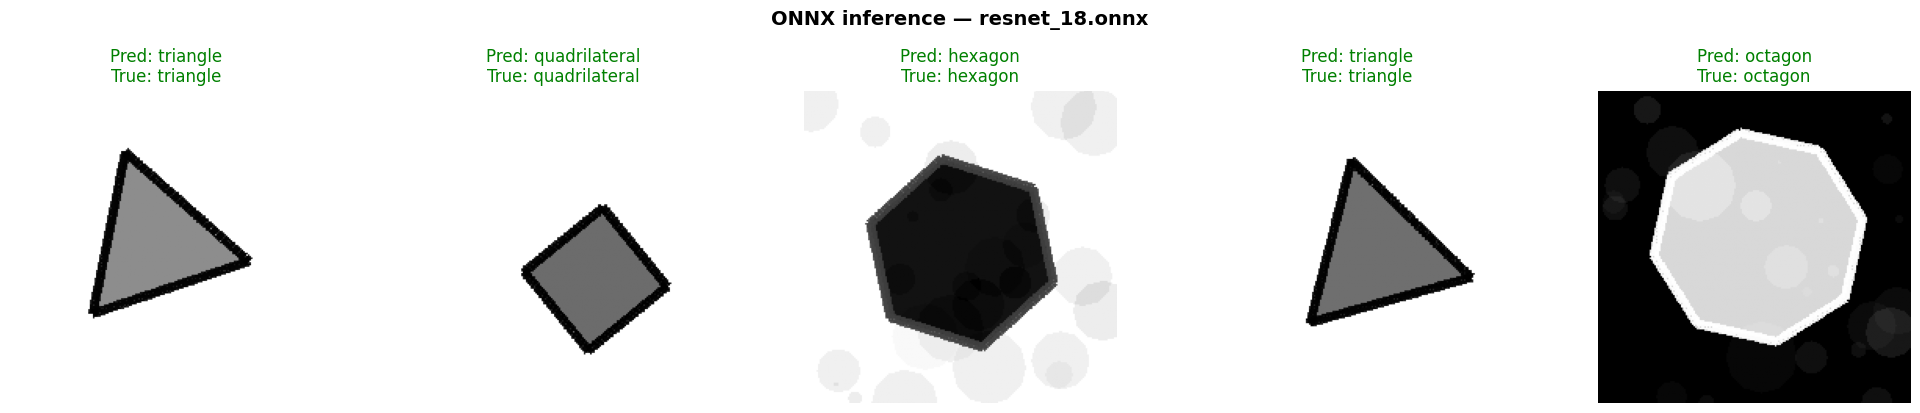

In [20]:
classifier.export_onnx(path="resnet_18.onnx")
classifier.verify_onnx(path="resnet_18.onnx")
classifier.infer_onnx(path="resnet_18.onnx")
